In [23]:
pwd

'/ictstr01/home/icb/ghaith.mqawass'

In [24]:
cd projs/morflow2.0/

/ictstr01/home/icb/ghaith.mqawass/projs/morflow2.0


In [25]:
# from sampling.samplers import  sample_flow,sample_flow_custom
from modules.lit_model import FlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import generate_mols

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/CrossEntropyLoss()_L=72_uniform_layers=12_dim=768_best-validity-epoch=121-validity=0.9350.ckpt'
model = FlowMolBERTLitModule.load_from_checkpoint(checkpoint_path)

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


In [40]:
dfm = model.model
dfm.eval()

FlowMolBERT(
  (tok_emb): Embedding(173, 767)
  (pos_emb): Embedding(72, 767)
  (time_emb): Linear(in_features=1, out_features=1, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (lm_head): Linear(in_features=768, out_features=173, bias=False)
)

In [41]:
torch.cuda.empty_cache()

In [46]:
torch.cuda.empty_cache()

In [142]:
import GPUtil

GPUs = GPUtil.getGPUs()
torch.cuda.empty_cache()
for gpu in GPUs:
    print(f"GPU id: {gpu.id}, name: {gpu.name}")
    print(f"  Memory Free: {gpu.memoryFree} MB")
    print(f"  Memory Used: {gpu.memoryUsed} MB")
    print(f"  Memory Total: {gpu.memoryTotal} MB")
    print(f"  GPU Load: {gpu.load*100}%")


GPU id: 0, name: NVIDIA A100-PCIE-40GB
  Memory Free: 22058.0 MB
  Memory Used: 18385.0 MB
  Memory Total: 40960.0 MB
  GPU Load: nan%


In [43]:
from tqdm import tqdm 
import torch
SEED = 50
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
val =[]
div = []
uniqueness = []
temps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8 , 0.9, 1]
for t in  tqdm(temps):
    samples = generate_mols(dfm, num_samples=1000,steps=100, device = 'cuda', temperature=t)
    total_samples = len(samples)
    _, smiles = decode_tokens_to_smiles(samples, ID2TOK=ID2TOK, TOK2ID=TOK2ID, PAD=PAD)
    metrics = compute_smiles_metrics(total_samples=total_samples, decoded_smiles=smiles)
    val.append(metrics['validity'])
    div.append(metrics['diversity'])
    uniqueness.append(metrics['uniqueness'])
    torch.cuda.empty_cache()


NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:30<00:00, 150.61s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 148.04s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.75s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:28<00:00, 148.97s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.77s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.77s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.81s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.87s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.78s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 148.01s/it]
100%|██████████| 10/10 [25:08<00:00, 150.85s/it]


In [45]:
metrics

{'validity': 0.917,
 'uniqueness': 1.0,
 'diversity': np.float64(0.8846398036814432)}

In [11]:
metrics # {'validity': 0.967,   400 steps, temprature = 0.5
 #'uniqueness': 0.9958634953464323,
 #'diversity': np.float64(0.8697108141226302)}

{'validity': 0.967,
 'uniqueness': 0.9958634953464323,
 'diversity': np.float64(0.8697108141226302)}

In [46]:
div

[np.float64(0.8560036656460205),
 np.float64(0.8576683947104858),
 np.float64(0.8647830143044196),
 np.float64(0.8700894568164708),
 np.float64(0.8754440175480954),
 np.float64(0.8772035588949698),
 np.float64(0.8800892612217822),
 np.float64(0.8817270657551914),
 np.float64(0.8845820565143137),
 np.float64(0.8846398036814432)]

In [47]:
val

[0.927, 0.95, 0.94, 0.944, 0.944, 0.939, 0.949, 0.934, 0.904, 0.917]

In [48]:
uniqueness

[0.9892125134843581,
 0.991578947368421,
 0.9968085106382979,
 1.0,
 1.0,
 1.0,
 0.9989462592202318,
 1.0,
 1.0,
 1.0]

In [159]:
# import pandas as pd
# df_generated = pd.DataFrame(smiles, columns=['smiles'])
# df_generated.to_parquet("/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated4.parquet")

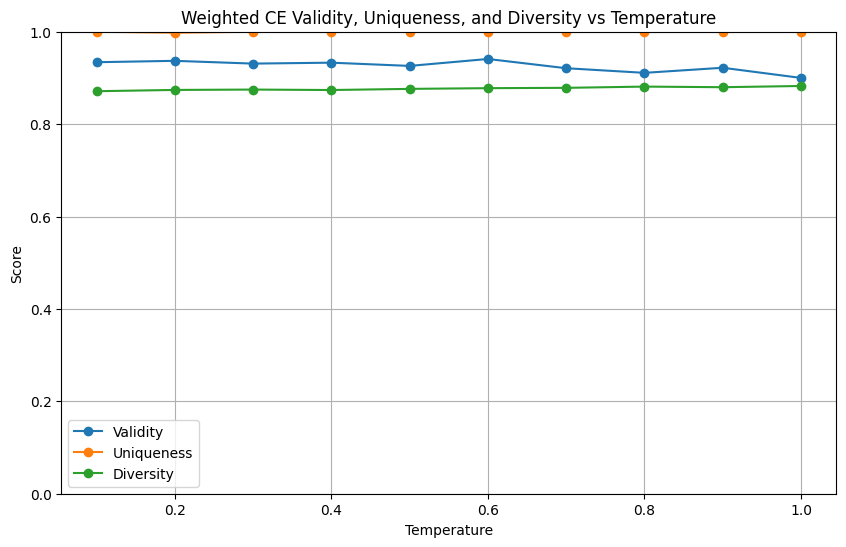

In [37]:
import matplotlib.pyplot as plt

# Example data
temperatures = [0.1 * i for i in range(1, 11)]  # [0.1, 0.2, ..., 1.0]
validity =    val
uniqueness =  uniqueness
diversity =   div

# Plot
plt.figure(figsize=(10, 6))

plt.plot(temperatures, validity, 'o-', label='Validity')
plt.plot(temperatures, uniqueness, 'o-', label='Uniqueness')
plt.plot(temperatures, diversity, 'o-', label='Diversity')

# Labels and title
plt.xlabel('Temperature')
plt.ylabel('Score')
plt.title('Weighted CE Validity, Uniqueness, and Diversity vs Temperature')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Show plot
plt.show()


### Properties evaluation

In [227]:
import swifter
import safe
import pandas as pd
from safe import encode, split, SAFEFragmentationError
from rdkit import Chem

In [229]:

df_main = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_with_chem_props.parquet')
df_gen1 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated_with_props.parquet')
df_gen2 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated2_with_props.parquet')
df_gen3 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated3_with_props.parquet')
df_gen4 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated4_with_props.parquet')

In [231]:
def tokenize_and_pad_smiles_safe(smiles: str, max_len: int = 72) -> list[str]:
    try:
        encoded = encode(smiles)
        tokens = split(encoded)
        padded = tokens[:max_len] + [' '] * (max_len - len(tokens))
        return padded
    except Exception as e:  # Can also catch SAFEFragmentationError specifically
        # Return a special token list or empty padding if encoding fails
        return ['<ERR>'] + [''] * (max_len - 1)
def count_fragments(tokens: list[str]) -> int:
    return tokens.count('.') + 1 

def count_connected_components(smiles: str) -> int:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return len(Chem.GetMolFrags(mol))

In [232]:
df_gen = pd.concat([df_gen1,df_gen2,df_gen3,df_gen4],ignore_index=True)

In [236]:
df_gen['safe_tokens']= df_gen['smiles'].swifter.apply(tokenize_and_pad_smiles_safe)
df_gen['num_fragments']= df_gen['safe_tokens'].swifter.apply(count_fragments)
df_gen['num_components']= df_gen['smiles'].swifter.apply(count_connected_components)

Pandas Apply: 100%|██████████| 18395/18395 [00:03<00:00, 5965.22it/s]


In [248]:
df_main['num_fragments']= df_main['safe_tokens'].swifter.apply(count_fragments)
df_main['num_components']= df_main['SMILES_standard'].swifter.apply(count_connected_components)

Pandas Apply: 100%|██████████| 1461513/1461513 [03:38<00:00, 6689.60it/s]


In [249]:
df_main = df_main[df_main.seq_len<=MAX_LEN]

In [250]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Step 1: Flatten all tokens into one list
all_tokens_gen = [token for row in df_gen['safe_tokens'] for token in row]
all_tokens_orig = [
    token for row in df_main['safe_tokens']
    for token in row if token not in {',', "'",']','['}
]
token_counts_gen = Counter(all_tokens_gen)
token_counts_orig = Counter(all_tokens_orig)
token_df = pd.DataFrame.from_dict(token_counts_orig, orient='index', columns=['count'])
token_df.sort_values('count', ascending=False, inplace=True)
token_df['probability'] = token_df['count'] / token_df['count'].sum()
token_df_gen = pd.DataFrame.from_dict(token_counts_gen, orient='index', columns=['count'])
token_df_gen.sort_values('count', ascending=False, inplace=True)
token_df_gen['probability'] = token_df_gen['count'] / token_df_gen['count'].sum()


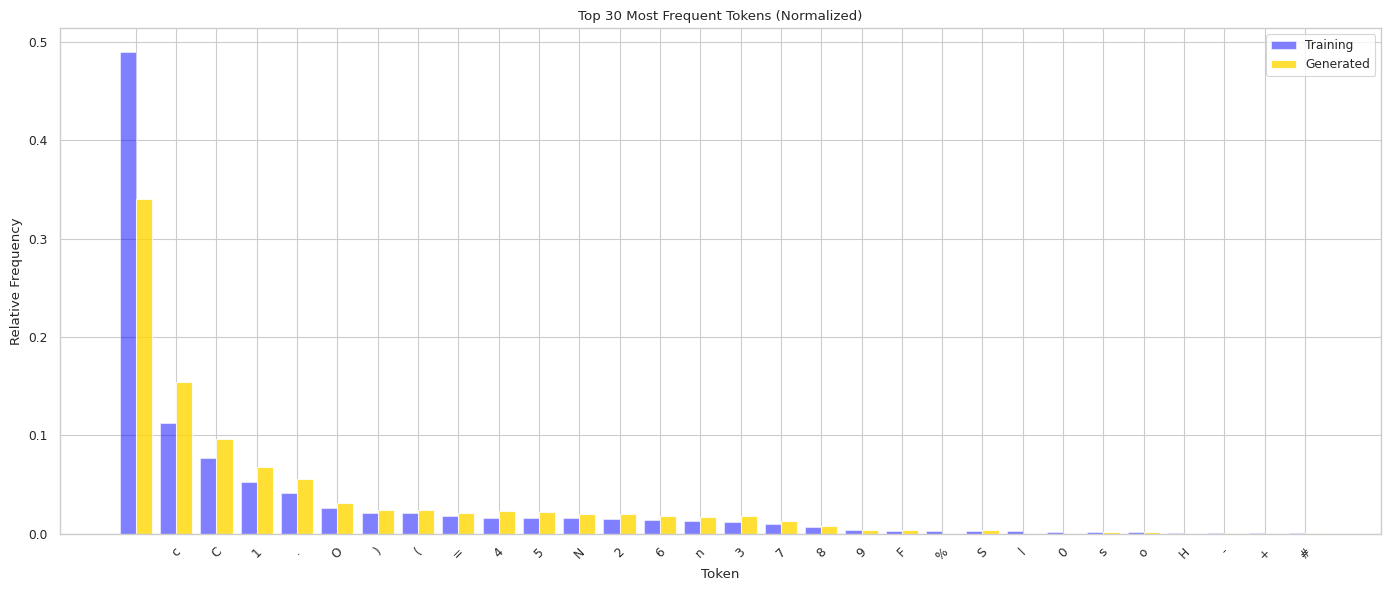

In [255]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# sns.set(style='whitegrid', context='talk', palette='deep') 
sns.set_context("paper")
 
# Align both to same top N tokens
top_n = 30
top_tokens = token_df.sort_values(by='probability', ascending=False).head(top_n).index
orig_top = token_df.reindex(top_tokens).fillna(0)
gen_top = token_df_gen.reindex(top_tokens).fillna(0)

# Set positions
x = np.arange(len(top_tokens))  # the label locations
width = 0.4  # width of the bars

# Create plot
fig, ax = plt.subplots(figsize=(14, 6))
bar1 = ax.bar(x - width/2, orig_top['probability'], width, label='Training', color='blue', alpha=0.5)
bar2 = ax.bar(x + width/2, gen_top['probability'], width, label='Generated', color='gold', alpha=0.8)

# Labels, legend, etc.
ax.set_title('Top 30 Most Frequent Tokens (Normalized)')
ax.set_xlabel('Token')
ax.set_ylabel('Relative Frequency')
ax.set_xticks(x)
ax.set_xticklabels(top_tokens, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


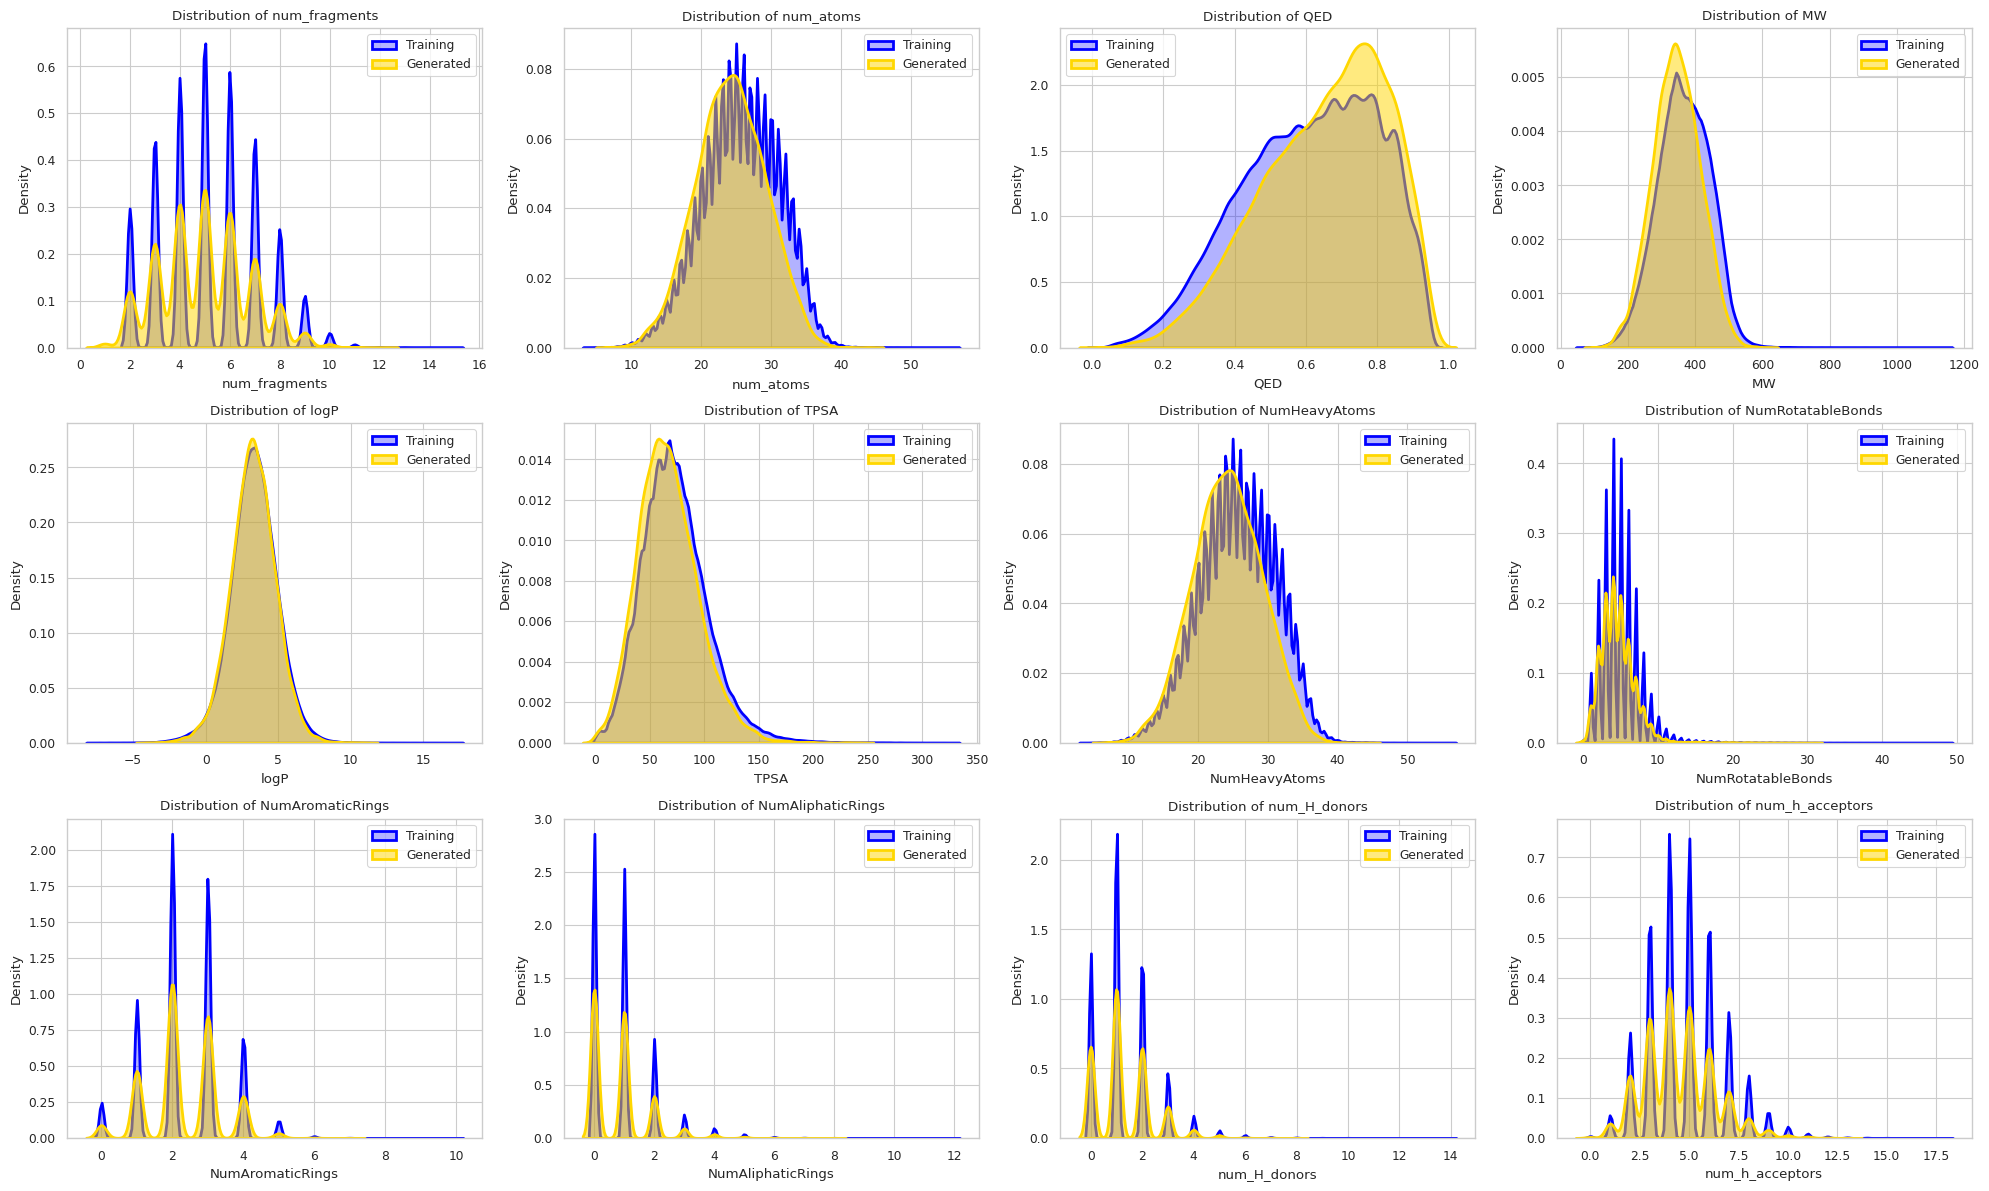

In [253]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of properties to compare
properties = [
    "num_fragments","num_atoms", "QED", "MW", "logP", "TPSA", "NumHeavyAtoms",
    "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
    "num_H_donors", "num_h_acceptors", 
]

# Set up the plot grid
n_cols = 4
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

# Plot each property in a subplot
for i, prop in enumerate(properties):
    ax = axes[i]

    # KDE plot for training set
    sns.kdeplot(df_main[prop].dropna(), fill=True, color='blue', label='Training',
                alpha=0.3, linewidth=2, ax=ax)

    # KDE plot for generated set
    sns.kdeplot(df_gen[prop].dropna(), fill=True, color='gold', label='Generated',
                alpha=0.5, linewidth=2, ax=ax)

    ax.set_title(f"Distribution of {prop}")
    ax.set_xlabel(prop)
    ax.set_ylabel("Density")
    ax.legend()

# Remove empty subplots if properties < n_rows * n_cols
for j in range(len(properties), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [282]:
s = df_gen[df_gen.QED>0.9]['smiles'].iloc[200]

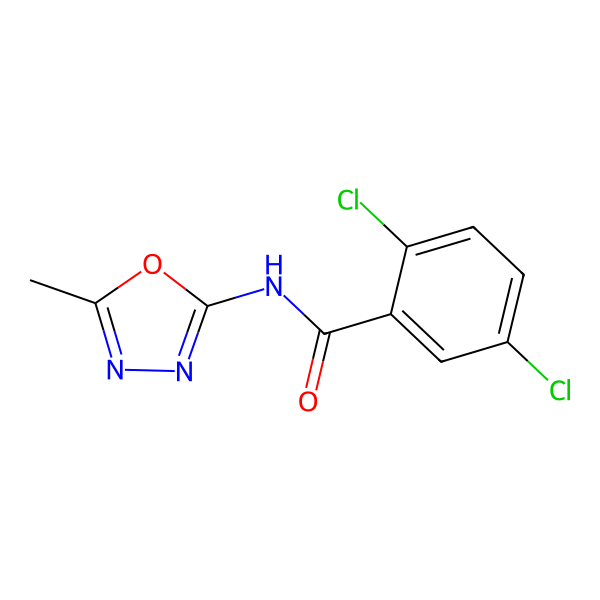

In [284]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D

mol = Chem.MolFromSmiles(s)

drawer = rdMolDraw2D.MolDraw2DSVG(600, 600)  # width, height in px
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

# Save to file
with open("molecule5.png", "w") as f:
    f.write(svg)

# You can display SVG inline in Jupyter too:
from IPython.display import SVG, display
display(SVG(svg))

## Conditional Modeling

In [1]:
pwd

'/ictstr01/home/icb/ghaith.mqawass'

In [2]:
cd projs/morflow2.0/

/ictstr01/home/icb/ghaith.mqawass/projs/morflow2.0


In [3]:
import pandas as pd
from tqdm import tqdm
import numpy as np

In [4]:
# df_cond = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/train_set_30kcpds_normalized_profiles.parquet')
# df = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_main_wconditions.parquet')
df= pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_with_chem_props.parquet')


In [5]:
from modules.cond_lit_model import CondFlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import  cond_generate_mols

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/last-v9.ckpt'
model = CondFlowMolBERTLitModule.load_from_checkpoint(checkpoint_path)
cfm = model.model
cfm.eval()

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


CondFlowMolBERT(
  (tok_emb): Embedding(173, 767)
  (pos_emb): Embedding(72, 767)
  (time_emb): Linear(in_features=1, out_features=1, bias=True)
  (cond_proj): Sequential(
    (0): Linear(in_features=11, out_features=1024, bias=True)
    (1): ReLU()
    (2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=1024, out_features=767, bias=True)
    (4): ReLU()
    (5): LayerNorm((767,), eps=1e-05, elementwise_affine=True)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=767, out_features=767, bias=True)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=768, b

In [8]:
from torch.utils.data import DataLoader, random_split
from data import  CondMolDataset

df = df[df["seq_len"] <= 72]
df = df.iloc[:100000,:]   #similar size to the perturbation data sizels -ls
df = df.reset_index(drop=True)  # to ensure 0-based indexing
df["original_index"] = df.index 
# df_conditioned = df[df['has_condition']==True]   #train with samples that have conditions only
encoded = df["encoded"].apply(lambda x: x[:data.MAX_LEN]).tolist()
condition = df.iloc[:,-12:-1]  #conditions_are 11 chem_props
label = [True] * df.shape[0]
indices = df["original_index"].tolist()
dataset = CondMolDataset(encoded,condition,label,indices)
# train_val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_indices = [item[3] for item in train_dataset]
val_indices = [item[3] for item in val_dataset]
df_train = df.loc[train_indices]
df_val = df.loc[val_indices]

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cond_scaled = scaler.fit_transform(np.array(df_train.iloc[:,-12:-1]))

In [19]:
df_train.iloc[:,-12:-1]

,num_atoms,QED,MW,logP,TPSA,NumHeavyAtoms,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,num_H_donors,num_h_acceptors
34165,23,0.667329,298.389,5.12582,25.78,23,4,3,0,0,2
85133,21,0.844957,354.837,0.39840,106.77,21,3,1,1,1,5
88873,17,0.620999,231.295,1.89390,38.33,17,5,1,1,1,3
55260,28,0.380062,463.365,2.60920,94.45,28,10,0,1,2,7
42318,32,0.230630,515.791,5.64970,84.50,32,8,3,0,2,4
...,...,...,...,...,...,...,...,...,...,...,...
30347,21,0.812025,292.335,1.00864,76.66,21,4,1,1,2,4
92584,29,0.701688,400.356,4.15030,70.50,29,2,3,1,1,3
41869,27,0.633738,375.493,4.97502,37.38,27,2,3,2,0,2
86484,26,0.703441,373.840,3.13674,87.30,26,5,2,0,3,3


In [122]:
train_props_means =[]
train_props_stds =[]
for i in range(11):
    train_props_means.append((df_train.iloc[:,-12 +i].mean()))
    train_props_stds.append((df_train.iloc[:,-12 +i].std()))
casted_props = []
for idx,prop in enumerate(train_props_means):
    if(idx in [1,2,3,4]):
        casted_props.append(prop)
    else:
        casted_props.append(np.round(prop))

In [143]:
train_props_means, train_props_stds

([25.624277777777777,
  0.6114319028138575,
  365.1488741222223,
  3.3029537637777793,
  72.57188255555556,
  25.624277777777777,
  5.029233333333333,
  2.3657777777777778,
  0.8491333333333333,
  1.3272777777777778,
  4.779044444444445],
 [5.383886389844645,
  0.18612105191126332,
  76.65637766635281,
  1.6227926532430268,
  30.228909963097404,
  5.383886389844645,
  2.650423680691762,
  1.0912469237601898,
  0.9766409907181723,
  1.1303210491874747,
  1.8337558315676694])

In [144]:
avg_props = scaler.transform(np.array(casted_props).reshape(1,-1))
props_qed_increased = np.array(casted_props)
props_qed_increased[1]= 0.8
props_qed_increased_scaled = scaler.transform(props_qed_increased.reshape(1,-1))


In [145]:
avg_condition_vector = torch.tensor(np.array(avg_props), dtype = torch.float32)
condition_vector_qed_increased = torch.tensor(np.array(props_qed_increased_scaled), dtype = torch.float32)

In [146]:
condition_vector_qed_increased

tensor([[ 0.0698,  1.0132,  0.0000,  0.0000,  0.0000,  0.0698, -0.0110, -0.3352,
          0.1545, -0.2895,  0.1205]])

In [166]:
from tqdm import tqdm 
import torch
device = 'cuda'
SEED = 50
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
val =[]
div = []
uniqueness = []
samples = cond_generate_mols(cfm,cond=condition_vector_qed_increased,source_distribution='uniform',guidance_scale=0.0,num_samples=5000,steps=100, device = 'cuda', temperature=1)
total_samples = len(samples)
_, smiles = decode_tokens_to_smiles(samples, ID2TOK=ID2TOK, TOK2ID=TOK2ID, PAD=PAD)
torch.cuda.empty_cache()

NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [12:20<00:00, 741.51s/it]


In [167]:
len(smiles)

4434

In [149]:
import logging
from typing import List, Dict, Collection, Optional, Union
import numpy as np
from rdkit import Chem, RDLogger
from rdkit.Chem import QED, Descriptors
from rdkit.Chem import Lipinski
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import swifter
from rdkit.Chem.rdMolDescriptors import CalcNumAliphaticRings
# Mute RDKit logging
RDLogger.logger().setLevel(RDLogger.CRITICAL)

logger = logging.getLogger(__name__)
logger.addHandler(logging.NullHandler())


In [168]:
def get_mol(smiles_str: Collection[str]) -> List[Optional[Chem.Mol]]:

    if smiles_str is None:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles_str)
    except Exception:
        mol = None
    return mol
def is_valid(smiles: str) -> bool:
    return Chem.MolFromSmiles(smiles) is not None

def is_sanitize_valid(mol: Chem.Mol) -> bool:
    if mol is None:
        return False
    try:
        Chem.SanitizeMol(mol)
        return True
    except:
        return False

In [169]:
count = 0
for s in smiles:
    if s in df.SMILES_standard:
        count+=1

In [170]:
def compute_properties_for_single(smiles: str) -> Dict[str, Union[float, bool]]:
    m = get_mol(smiles) # Get single mol
    return {
        "SMILES": smiles,
        "Valid": is_valid(smiles),
        "Sanitize": is_sanitize_valid(m),
        "num_atoms": m.GetNumAtoms() if m is not None else float('nan'),
        "QED": QED.qed(m) if m is not None else float('nan'),
        "MW": Descriptors.MolWt(m) if m is not None else float('nan'),
        "logP": Descriptors.MolLogP(m) if m is not None else float('nan'),
        "TPSA": Descriptors.TPSA(m) if m is not None else float('nan'),
        "NumHeavyAtoms": m.GetNumHeavyAtoms() if m is not None else float('nan'),
        "NumRotatableBonds": Descriptors.NumRotatableBonds(m) if m is not None else float('nan'),
        "NumAromaticRings": Descriptors.NumAromaticRings(m) if m is not None else float('nan'),
        "NumAliphaticRings": CalcNumAliphaticRings(m) if m is not None else float('nan'),
        "num_H_donors": Lipinski.NumHDonors(m) if m is not None else float('nan'),
        "num_h_acceptors": Lipinski.NumHAcceptors(m) if m is not None else float('nan'),
    }

In [171]:
df_props = []
for smi in smiles:
    df_props.append(compute_properties_for_single(smi))
properties_df = pd.json_normalize(df_props)


In [172]:
properties_df.logP.mean()

3.199016871898964

In [173]:
properties_df

,SMILES,Valid,Sanitize,num_atoms,QED,MW,logP,TPSA,NumHeavyAtoms,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,num_H_donors,num_h_acceptors
0,CC.Cc1cc2ncc(C(=O)OCCCN3CCNCC3)c(O)c2cc1C,True,True,27,0.619827,373.497,3.03554,74.69,27,5,2,1,2,6
1,N#Cc1ccc(OC2CC(Cc3cccc(C(F)(F)F)n3)CC2N)cc1,True,True,26,0.901293,361.367,3.69948,71.93,26,4,2,1,1,4
2,Cc1nn(CCc2ccccc2C(C)C)c2c1C(N1CCCC1)=C(Cl)C2=O,True,True,27,0.746796,383.923,4.75712,38.13,27,5,2,2,0,4
3,Cc1ccc(N(NC(=O)COC(=O)c2ccncc2)C2CCCC2)cc1,True,True,26,0.638368,353.422,3.02722,71.53,26,6,2,1,1,5
4,N#CC1CCCN1CCCCNC(=O)c1csc(-c2c(F)cccc2Cl)n1,True,True,27,0.702590,406.914,4.10058,69.02,27,7,2,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4429,CN1CCN(C(=O)Nc2ccnc(SCc3cc(Cl)ccc3F)n2)CC1,True,True,26,0.635114,395.891,3.34070,61.36,26,4,2,1,1,5
4430,Cc1cc(C)n2nc(C(C)NC(=O)CN3CCCc4ccccc43)nc2n1,True,True,27,0.769191,364.453,2.37114,75.42,27,4,3,1,1,6
4431,COc1cc2c(cc1OC)C(=O)C(NC(=O)CCl)(c1ccccc1)OC2,True,True,26,0.813088,375.808,2.62470,73.86,26,5,2,1,1,5
4432,CCOC(=O)C1=C(N)N(c2ccccc2)CC(=O)N1c1ccccc1OC,True,True,27,0.816080,367.405,2.23930,85.10,27,5,2,1,1,6


In [174]:
gen_props_means =[]
gen_props_stds =[]
for i in range(11):
    gen_props_means.append((properties_df.iloc[:,-11 +i].mean()))
    gen_props_stds.append(properties_df.iloc[:,-11 +i].std())

In [175]:
train_props_means, train_props_stds

([25.624277777777777,
  0.6114319028138575,
  365.1488741222223,
  3.3029537637777793,
  72.57188255555556,
  25.624277777777777,
  5.029233333333333,
  2.3657777777777778,
  0.8491333333333333,
  1.3272777777777778,
  4.779044444444445],
 [5.383886389844645,
  0.18612105191126332,
  76.65637766635281,
  1.6227926532430268,
  30.228909963097404,
  5.383886389844645,
  2.650423680691762,
  1.0912469237601898,
  0.9766409907181723,
  1.1303210491874747,
  1.8337558315676694])

In [176]:
gen_props_means, gen_props_stds

([26.318222823635544,
  0.759507182175509,
  371.85528958051435,
  3.199016871898964,
  74.8391700496166,
  26.318222823635544,
  4.8824988723500224,
  1.9968425800631484,
  1.1461434370771313,
  1.1172755976544881,
  5.088182228236356],
 [0.9396386166744292,
  0.12083305792504637,
  17.160876415764267,
  0.7987110859464123,
  13.53786712936392,
  0.9396386166744292,
  1.1724506940307797,
  0.2817702875601043,
  0.49888191089050826,
  0.6871277372017994,
  0.9382611729121753])

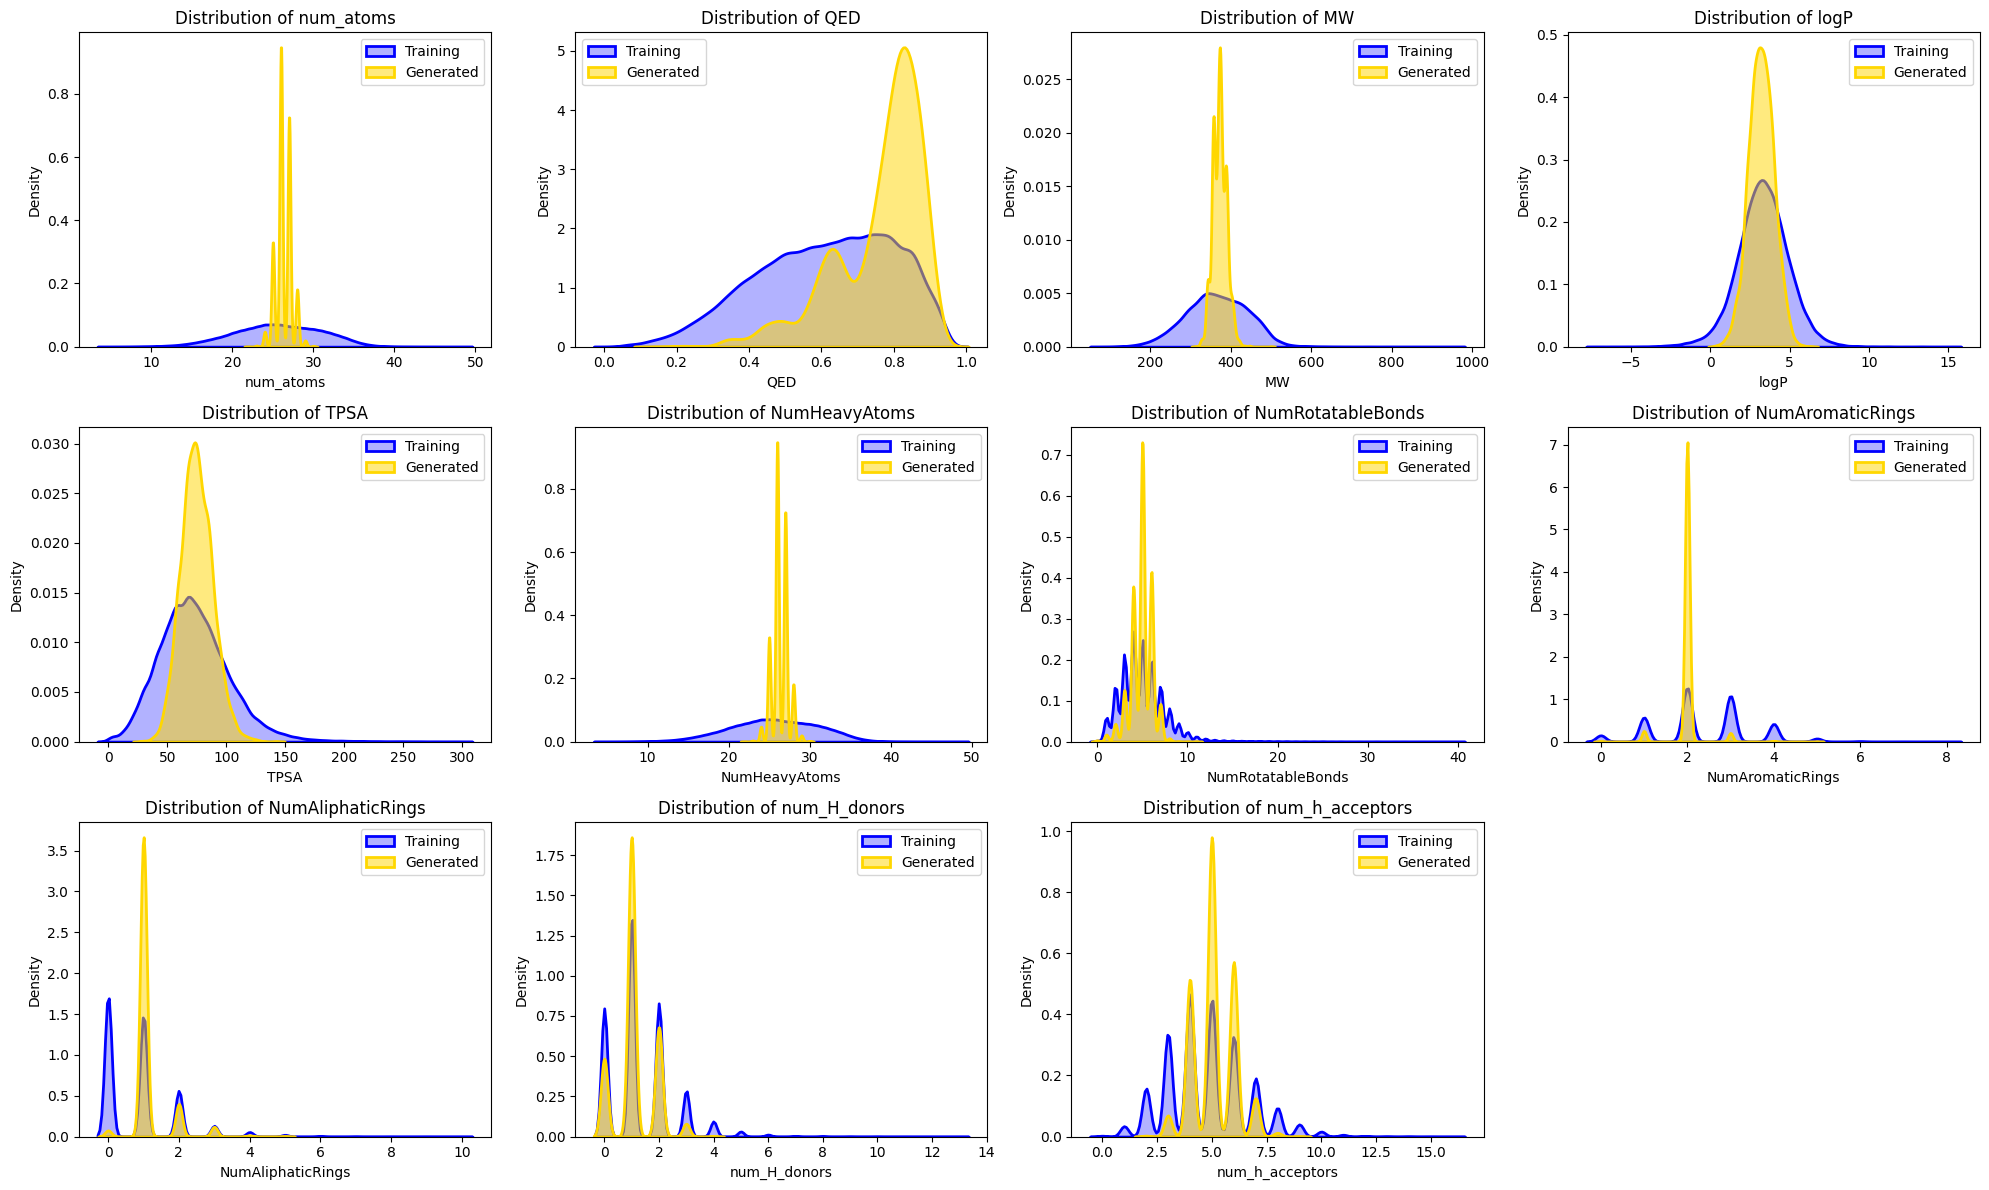

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of properties to compare
properties = [
    "num_atoms", "QED", "MW", "logP", "TPSA", "NumHeavyAtoms",
    "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
    "num_H_donors", "num_h_acceptors", 
]

# Set up the plot grid
n_cols = 4
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

# Plot each property in a subplot
for i, prop in enumerate(properties):
    ax = axes[i]

    # KDE plot for training set
    sns.kdeplot(df_train[prop].dropna(), fill=True, color='blue', label='Training',
                alpha=0.3, linewidth=2, ax=ax)

    # KDE plot for generated set
    sns.kdeplot(properties_df[prop].dropna(), fill=True, color='gold', label='Generated',
                alpha=0.5, linewidth=2, ax=ax)

    ax.set_title(f"Distribution of {prop}")
    ax.set_xlabel(prop)
    ax.set_ylabel("Density")
    ax.legend()

# Remove empty subplots if properties < n_rows * n_cols
for j in range(len(properties), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Analysis of perturbation data

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet ('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_main_wconditions.parquet')

In [51]:
# df_uncond = df[df['has_condition']==False].sample(n=94105, random_state=42) 

In [41]:
df_cond = df[(df['has_condition']==True) & (df.seq_len<=72)]

In [42]:
df_cond.iloc[:,-1450:-1]

,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,Cells_AreaShape_Extent,Cells_AreaShape_FormFactor,Cells_AreaShape_MajorAxisLength,Cells_AreaShape_MaxFeretDiameter,Cells_AreaShape_MaximumRadius,Cells_AreaShape_MeanRadius,...,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0,has_condition
41,2.314919,0.746245,0.790115,-0.014804,-2.220936,0.015262,-0.282345,-0.310876,-0.926161,-0.601916,...,-1.975379,-1.537216,-1.694384,-2.010195,-1.523325,-1.923111,-0.721703,-0.715398,-0.727716,True
42,-0.777379,0.149887,2.828240,2.061217,-2.516237,-0.103453,0.728947,0.757317,-0.692783,-0.723258,...,-1.541783,-1.810282,-1.424348,-2.175736,-3.025378,-2.738477,-0.819643,-0.848581,-0.999255,True
43,1.287664,0.146628,0.995885,1.502253,-0.916408,-0.380869,0.500023,0.554712,-0.798817,-0.851473,...,2.077431,1.447079,1.966638,-0.810950,-1.186248,-0.916034,0.138561,0.185454,0.275543,True
44,0.621796,0.337245,0.130425,0.323302,-0.552423,-1.016340,1.149204,1.183307,2.179151,2.056098,...,-0.544909,-0.861115,-1.197857,-0.804342,-0.327998,-0.195914,-1.334798,-1.339023,-1.545277,True
103,0.032902,0.858443,-0.996262,-1.051054,0.485349,0.572209,-0.888975,-0.802617,-0.155826,0.302925,...,-0.257138,0.040612,0.642153,1.675547,1.192460,1.617220,0.153353,-0.475143,-0.231460,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569903,-0.044966,0.049962,2.003443,1.462058,-2.275085,1.534041,-0.090299,-0.136641,-0.914476,-1.140678,...,-0.797883,-0.593471,-0.493009,-1.244405,-2.110788,-1.836207,-1.274073,-2.301869,-1.711431,True
1570027,-0.773197,0.030659,0.041698,0.520923,0.615781,-0.224689,-1.836850,-1.662979,-1.473157,-1.897050,...,-0.457203,-0.602982,-0.547415,0.718081,0.439811,0.590267,-0.874343,-0.684231,-0.800881,True
1570028,-0.733509,0.846420,0.543788,0.525275,0.361519,1.308120,0.009190,-0.258397,-0.416540,-0.271687,...,2.295507,2.995736,2.664799,2.127725,1.240653,2.348788,1.051124,0.903840,1.239163,True
1570029,-0.483217,-0.301368,-0.085434,0.466976,0.764928,0.660188,-2.544781,-3.071886,-3.545717,-2.660706,...,1.984188,1.634704,1.497178,2.264390,1.183333,1.384463,2.857784,2.155025,3.448053,True


In [43]:
cond_data = df_cond.iloc[:, -1450:-1]

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
cond_scaled = scaler.fit_transform(np.array(cond_data))
pca = PCA(n_components=2)  
cond_pca = pca.fit_transform(cond_scaled)

In [45]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(cond_pca)
centroids = kmeans.cluster_centers_     

In [52]:
len(kmeans.labels_)

94105

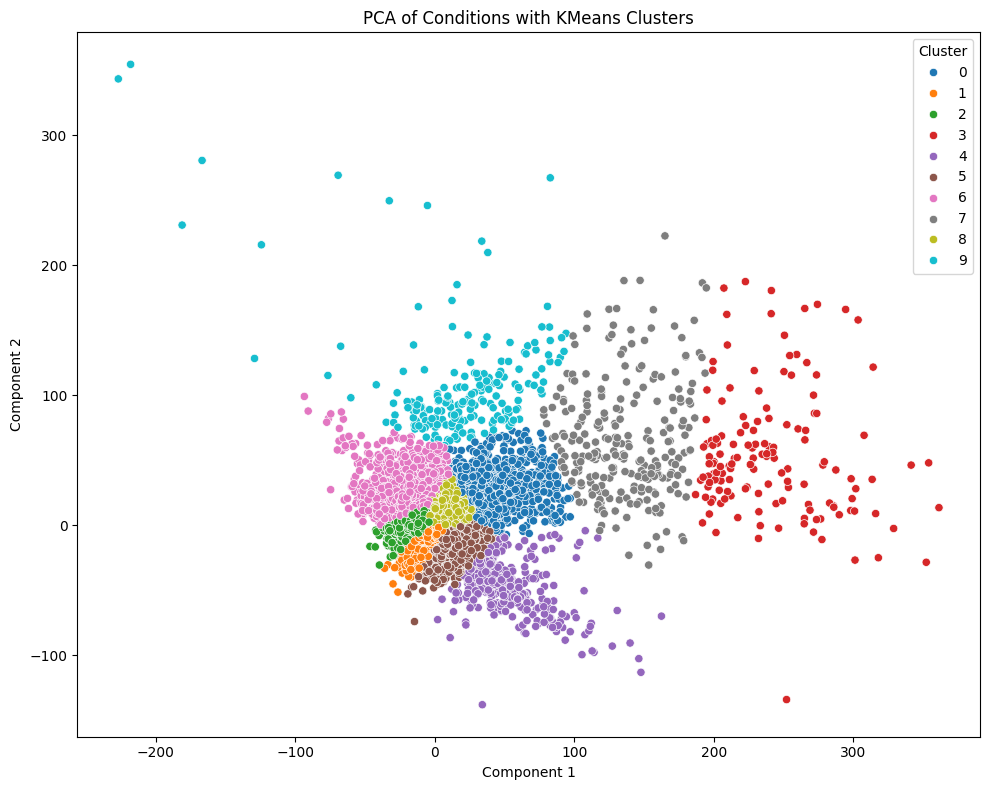

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.scatterplot(x=cond_pca[:, 0], y=cond_pca[:, 1], hue=cluster_labels, palette='tab10')
plt.title("PCA of Conditions with KMeans Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

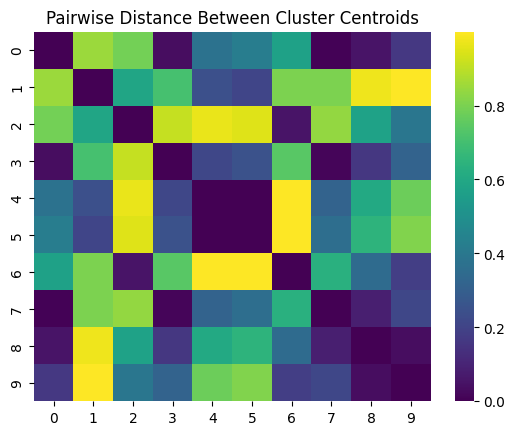

In [48]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity

cos_sim = cosine_similarity(centroids)  # range [-1,1]
distance = (1 - cos_sim) / 2  

# Plot as heatmap
sns.heatmap(distance, annot=False, cmap="viridis")
plt.title("Pairwise Distance Between Cluster Centroids")
plt.show()

In [70]:
from collections import Counter
# dmso_cluster_counts = Counter(kmeans.labels_[dmso_ids])

# print("Cluster labels for DMSO samples:", kmeans.labels_[dmso_ids])
# print("DMSO cluster sizes:", dmso_cluster_counts)

In [71]:
cluster_counts = Counter(kmeans.labels_)
print(cluster_counts)

Counter({1: 29896, 2: 23574, 5: 18171, 8: 14286, 6: 6295, 0: 869, 4: 413, 7: 252, 9: 203, 3: 146})


In [67]:
# df['cluster_id'] = -1 

In [57]:
df.loc[(df['has_condition']==True) & (df.seq_len<=72),'cluster_id'] = kmeans.labels_

In [60]:
# Get centroids
centroids = kmeans.cluster_centers_

# Compute distance of each point to its assigned centroid
# Use Euclidean distance here, but can use other metrics if you want
assigned_centroids = centroids[kmeans.labels_]

cos_sim = np.array([
    cosine_similarity(cond_pca[i:i+1], assigned_centroids[i:i+1])[0, 0]
    for i in range(len(cond_pca))
])
cos_dist = (1 - cos_sim) / 2


In [64]:
df['dist_to_centroid'] = -10

In [65]:
df.loc[(df['has_condition']==True) & (df.seq_len<=72),'dist_to_centroid'] = cos_dist

/tmp/ipykernel_3168302/2037270349.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.24658378 0.00285347 0.16233929 ... 0.21203714 0.055399   0.00227289]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df['has_condition']==True) & (df.seq_len<=72),'dist_to_centroid'] = cos_dist


In [66]:
df[(df['has_condition']==True) & (df.seq_len<=72)]

,SMILES_standard,SAFE,safe_tokens,seq_len,encoded,SMILES,Valid,Sanitize,num_atoms,QED,...,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0,has_condition,cluster_id,dist_to_centroid
41,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,-1.694384,-2.010195,-1.523325,-1.923111,-0.721703,-0.715398,-0.727716,True,1,0.246584
42,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,-1.424348,-2.175736,-3.025378,-2.738477,-0.819643,-0.848581,-0.999255,True,1,0.002853
43,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,1.966638,-0.810950,-1.186248,-0.916034,0.138561,0.185454,0.275543,True,8,0.162339
44,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,-1.197857,-0.804342,-0.327998,-0.195914,-1.334798,-1.339023,-1.545277,True,2,0.015785
103,CCn1c(COc2ccccc2C)nnc1SCC(=O)CC(=O)Nc1ccccc1OC,n19c%10nnc1%11.c15ccccc1C.C7C(=O)CC3=O.c18cccc...,"['n', '1', '9', 'c', '%10', 'n', 'n', 'c', '1'...",69,"[169, 98, 106, 168, 3, 169, 169, 168, 98, 4, 9...",CCn1c(COc2ccccc2C)nnc1SCC(=O)CC(=O)Nc1ccccc1OC,True,True,32,0.346904,...,0.642153,1.675547,1.192460,1.617220,0.153353,-0.475143,-0.231460,True,8,0.009278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569903,O=C(Cn1cc2c(n1)CCCC2)Nc1cc(-c2cccc(Cl)c2)no1,n15cc2c(n1)CCCC2.c16cccc(Cl)c1.c14cc6no1.O=C3C...,"['n', '1', '5', 'c', 'c', '2', 'c', '(', 'n', ...",50,"[169, 98, 102, 168, 168, 99, 168, 93, 169, 98,...",O=C(Cn1cc2c(n1)CCCC2)Nc1cc(-c2cccc(Cl)c2)no1,True,True,25,0.773000,...,-0.493009,-1.244405,-2.110788,-1.836207,-1.274073,-2.301869,-1.711431,True,1,0.039737
1570027,CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,c18ccc(Cl)cc1.n15nnnc16.CCC5(C)C.c17ccco1.N234...,"['c', '1', '8', 'c', 'c', 'c', '(', 'Cl', ')',...",57,"[168, 98, 105, 168, 168, 168, 93, 111, 94, 168...",CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,True,True,26,0.589794,...,-0.547415,0.718081,0.439811,0.590267,-0.874343,-0.684231,-0.800881,True,5,0.007604
1570028,CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,c18ccc(Cl)cc1.n15nnnc16.CCC5(C)C.c17ccco1.N234...,"['c', '1', '8', 'c', 'c', 'c', '(', 'Cl', ')',...",57,"[168, 98, 105, 168, 168, 168, 93, 111, 94, 168...",CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,True,True,26,0.589794,...,2.664799,2.127725,1.240653,2.348788,1.051124,0.903840,1.239163,True,8,0.212037
1570029,CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,c18ccc(Cl)cc1.n15nnnc16.CCC5(C)C.c17ccco1.N234...,"['c', '1', '8', 'c', 'c', 'c', '(', 'Cl', ')',...",57,"[168, 98, 105, 168, 168, 168, 93, 111, 94, 168...",CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,True,True,26,0.589794,...,1.497178,2.264390,1.183333,1.384463,2.857784,2.155025,3.448053,True,0,0.055399


In [68]:
# df.to_parquet("/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_main_wconditions_clustered.parquet")

In [42]:
# cols_to_add = [col for col in df_cond.columns if col != 'SMILES_standard']

# # Merge with df_main on 'smiles', left join keeps all df_main rows
# df_merged = df_main.merge(df_cond[['SMILES_standard'] + cols_to_add], on='SMILES_standard', how='left') # fill nans where empty